In [1]:
from sklearn.metrics import mean_squared_error

# Valores reais
y_true = [3, -0.5, 2, 7]
# Valores previstos pelo modelo
y_pred = [2.5, 0.0, 2, 8]

# Calculando o MSE
mse = mean_squared_error(y_true, y_pred)
print("Mean Squared Error:", mse)
print('Quanto menor o valor, melhor o desempenho do modelo.')

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Imports
import pickle
import pandas as pd
import numpy as np
import xgboost as xgb
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set(style = "whitegrid")
%matplotlib inline

In [ ]:
df = pd.read_csv('dados_originais.csv')

In [ ]:
df.shape

(11500, 180)

In [ ]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed: 0 to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


In [ ]:
df['y'].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

In [ ]:
# Colocando True onde o valor for igual a 1 e False onde o valor for diferente.
df["LABEL_VARIAVEL_TARGET"] = df.y == 1

In [ ]:
df.pop('y')

0        4
1        1
2        5
3        5
4        5
        ..
11495    2
11496    1
11497    5
11498    3
11499    4
Name: y, Length: 11500, dtype: int64

In [ ]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,LABEL_VARIAVEL_TARGET
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,False
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,True
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,False
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,False
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,False


In [ ]:
df.drop(df.columns[0], axis = 1, inplace = True)

In [ ]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,LABEL_VARIAVEL_TARGET
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,False
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,True
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,False
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,False
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,False


In [ ]:
print("Número de colunas:", len(df.columns))

Número de colunas: 179


In [ ]:
# Resumo estatístico
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-9.498870,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,165.235574,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1860.000000,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-8.000000,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,35.000000,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,2047.000000,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000


In [ ]:
# Verificando se há valores ausentes
df.isnull().values.any()

False

In [ ]:
lista_de_colunas = df.columns.tolist()

In [ ]:
lista_de_colunas

['X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X6',
 'X7',
 'X8',
 'X9',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X16',
 'X17',
 'X18',
 'X19',
 'X20',
 'X21',
 'X22',
 'X23',
 'X24',
 'X25',
 'X26',
 'X27',
 'X28',
 'X29',
 'X30',
 'X31',
 'X32',
 'X33',
 'X34',
 'X35',
 'X36',
 'X37',
 'X38',
 'X39',
 'X40',
 'X41',
 'X42',
 'X43',
 'X44',
 'X45',
 'X46',
 'X47',
 'X48',
 'X49',
 'X50',
 'X51',
 'X52',
 'X53',
 'X54',
 'X55',
 'X56',
 'X57',
 'X58',
 'X59',
 'X60',
 'X61',
 'X62',
 'X63',
 'X64',
 'X65',
 'X66',
 'X67',
 'X68',
 'X69',
 'X70',
 'X71',
 'X72',
 'X73',
 'X74',
 'X75',
 'X76',
 'X77',
 'X78',
 'X79',
 'X80',
 'X81',
 'X82',
 'X83',
 'X84',
 'X85',
 'X86',
 'X87',
 'X88',
 'X89',
 'X90',
 'X91',
 'X92',
 'X93',
 'X94',
 'X95',
 'X96',
 'X97',
 'X98',
 'X99',
 'X100',
 'X101',
 'X102',
 'X103',
 'X104',
 'X105',
 'X106',
 'X107',
 'X108',
 'X109',
 'X110',
 'X111',
 'X112',
 'X113',
 'X114',
 'X115',
 'X116',
 'X117',
 'X118',
 'X119',
 'X120',
 'X121',
 'X122',
 'X123',
 

In [ ]:
colunas_entrada = lista_de_colunas[0:178]

In [ ]:
print(colunas_entrada)

['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X72', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'X101', 'X102', 'X103', 'X104', 'X105', 'X106', 'X107', 'X108', 'X109', 'X110', 'X111', 'X112', 'X113', 'X114', 'X115', 'X116', 'X117', 'X118', 'X119', 'X120', 'X121', 'X122', 'X123', 'X124', 'X125', 'X126', 'X127', 'X128', 'X129', 'X130', 'X131', 'X132', 'X133', 'X134', 'X135', 'X136', 'X137', 'X138', 'X1

In [ ]:
# Checando se temos colunas duplicadas nos dados de entrada
dup_cols = set([x for x in colunas_entrada if colunas_entrada.count(x) > 1])
print(dup_cols)
assert len(dup_cols) == 0, "você duplicou colunas em cols_input"

set()


In [ ]:
# Checando se temos colunas duplicadas no dataset completo
dup_cols = set([x for x in lista_de_colunas if lista_de_colunas.count(x) > 1])
print(dup_cols)
assert len(dup_cols) == 0,'você duplicou colunas em lista_de_colunas'

set()


In [ ]:
# Categorias da variável alvo
df.LABEL_VARIAVEL_TARGET.value_counts()

LABEL_VARIAVEL_TARGET
False    9200
True     2300
Name: count, dtype: int64

In [ ]:
# Esta função calcula a prevalência da classe positiva (label = 1)
def calcula_prevalencia(y_actual):
    return sum(y_actual) / len(y_actual)

In [ ]:
print("Prevalência da classe positiva: %.3f"% 
      calcula_prevalencia(df["LABEL_VARIAVEL_TARGET"].values))

Prevalência da classe positiva: 0.200


In [ ]:
# Gerando amostras aleatórias dos dados
df_data = df.sample(n = len(df))

In [ ]:
# Ajustando os índices do dataset
df_data = df_data.reset_index(drop = True)

In [ ]:
df_data

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,LABEL_VARIAVEL_TARGET
0,12,13,24,39,39,28,20,11,15,15,...,-34,-12,19,38,54,39,23,2,-4,False
1,-1,3,3,1,-8,0,12,18,30,34,...,-6,2,9,4,5,-24,-22,-17,-19,False
2,-45,-45,-40,-47,-46,-41,-32,-20,-11,1,...,-22,-1,24,50,82,118,145,142,102,False
3,-53,-76,-39,-48,-86,-126,-150,-141,-103,-92,...,-32,-11,5,44,48,70,92,68,37,False
4,-58,-67,-64,-34,-5,23,25,-5,-45,-81,...,-33,-35,-23,-6,12,6,-11,-16,-20,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,34,21,16,11,24,38,51,65,68,63,...,-15,7,18,16,5,-14,-33,-51,-49,False
11496,-53,-37,-21,6,22,42,45,71,65,62,...,26,17,9,-3,-14,-28,-46,-57,-56,False
11497,-55,-27,-15,-16,-26,-5,0,-1,7,4,...,-101,-102,-120,-103,-94,-111,-129,-137,-142,False
11498,59,56,71,58,66,52,34,17,-2,0,...,-29,3,38,62,65,40,18,5,-6,False


In [ ]:
# Gera um índice para a divisão
df_valid_teste = df_data.sample(frac = 0.3)
print("Tamanho da divisão de validação / teste: %.1f" 
      % (len(df_valid_teste) / len(df_data)))

Tamanho da divisão de validação / teste: 0.3


In [ ]:
# Fazendo a divisão

# Dados de teste
df_teste = df_valid_teste.sample(frac = 0.5)

# Dados se validação
df_valid = df_valid_teste.drop(df_teste.index)

# Dados de treino
df_treino = df_data.drop(df_valid_teste.index)

In [ ]:
# Verifique a prevalência de cada subconjunto
print(
    "Teste(n = %d): %.2f"
    % (len(df_teste), calcula_prevalencia(df_teste.LABEL_VARIAVEL_TARGET.values))
)
print(
    "Validação(n = %d): %.2f"
    % (len(df_valid), calcula_prevalencia(df_valid.LABEL_VARIAVEL_TARGET.values))
)
print(
    "Treino(n = %d): %.2f"
    % (len(df_treino), calcula_prevalencia(df_treino.LABEL_VARIAVEL_TARGET.values))
)

Teste(n = 1725): 0.19
Validação(n = 1725): 0.21
Treino(n = 8050): 0.20


In [ ]:
print('Todas as amostras (n = %d)'%len(df_data))
assert len(df_data) == (len(df_teste)+len(df_valid) + len(df_treino)), 'algo saiu errado'

Todas as amostras (n = 11500)


In [ ]:
df_teste.shape

(1725, 179)

In [ ]:
df_valid.shape

(1725, 179)

In [ ]:
df_treino.shape

(8050, 179)

In [ ]:
df_treino.LABEL_VARIAVEL_TARGET.value_counts()

LABEL_VARIAVEL_TARGET
False    6441
True     1609
Name: count, dtype: int64

In [ ]:
df_treino

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,LABEL_VARIAVEL_TARGET
1,-1,3,3,1,-8,0,12,18,30,34,...,-6,2,9,4,5,-24,-22,-17,-19,False
3,-53,-76,-39,-48,-86,-126,-150,-141,-103,-92,...,-32,-11,5,44,48,70,92,68,37,False
4,-58,-67,-64,-34,-5,23,25,-5,-45,-81,...,-33,-35,-23,-6,12,6,-11,-16,-20,False
5,-103,-117,-115,-107,-98,-82,-65,-45,-15,14,...,-147,-146,-132,-114,-93,-72,-45,-36,-11,False
7,-61,23,163,266,349,384,422,467,523,558,...,327,-244,-676,-936,-860,-640,-509,-93,9,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11492,-44,-46,-60,-72,-77,-75,-68,-62,-54,-55,...,47,26,-3,-32,-67,-95,-111,-117,-123,False
11494,-2,-11,-26,-30,-37,-40,-36,-17,4,27,...,-41,-38,-36,-36,-23,-7,0,4,3,False
11495,34,21,16,11,24,38,51,65,68,63,...,-15,7,18,16,5,-14,-33,-51,-49,False
11497,-55,-27,-15,-16,-26,-5,0,-1,7,4,...,-101,-102,-120,-103,-94,-111,-129,-137,-142,False


In [ ]:
# Cria um índice com True/False
indice = df_treino.LABEL_VARIAVEL_TARGET == 1

In [ ]:
indice

1        False
3        False
4        False
5        False
7         True
         ...  
11492    False
11494    False
11495    False
11497    False
11498    False
Name: LABEL_VARIAVEL_TARGET, Length: 8050, dtype: bool

In [ ]:
# Define valores positivos e negativos do índice
df_train_pos = df_treino.loc[indice]
df_train_neg = df_treino.loc[~indice]

In [ ]:
df_train_neg

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,LABEL_VARIAVEL_TARGET
1,-1,3,3,1,-8,0,12,18,30,34,...,-6,2,9,4,5,-24,-22,-17,-19,False
3,-53,-76,-39,-48,-86,-126,-150,-141,-103,-92,...,-32,-11,5,44,48,70,92,68,37,False
4,-58,-67,-64,-34,-5,23,25,-5,-45,-81,...,-33,-35,-23,-6,12,6,-11,-16,-20,False
5,-103,-117,-115,-107,-98,-82,-65,-45,-15,14,...,-147,-146,-132,-114,-93,-72,-45,-36,-11,False
9,1,14,21,23,27,16,8,1,-4,-12,...,12,7,-10,-32,-47,-44,-37,-30,-18,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11492,-44,-46,-60,-72,-77,-75,-68,-62,-54,-55,...,47,26,-3,-32,-67,-95,-111,-117,-123,False
11494,-2,-11,-26,-30,-37,-40,-36,-17,4,27,...,-41,-38,-36,-36,-23,-7,0,4,3,False
11495,34,21,16,11,24,38,51,65,68,63,...,-15,7,18,16,5,-14,-33,-51,-49,False
11497,-55,-27,-15,-16,-26,-5,0,-1,7,4,...,-101,-102,-120,-103,-94,-111,-129,-137,-142,False


In [ ]:
# Valor mínimo de registros entre classe positiva e negativa
valor_minimo = np.min([len(df_train_pos), len(df_train_neg)])

In [ ]:
valor_minimo

1609

In [ ]:
# Obtém valores aleatórios para o dataset de treino
df_treino_final = pd.concat([df_train_pos.sample(n = valor_minimo, random_state = 69), 
                             df_train_neg.sample(n = valor_minimo, random_state = 69)], 
                            axis = 0, 
                            ignore_index = True)

In [ ]:
df_treino_final['LABEL_VARIAVEL_TARGET'].value_counts()

LABEL_VARIAVEL_TARGET
True     1609
False    1609
Name: count, dtype: int64

In [ ]:
# Amostragem aleatória do dataset de treino
df_treino_final = df_treino_final.sample(n = len(df_treino_final), random_state = 69).reset_index(drop = True)

In [ ]:
df_treino_final.shape

(3218, 179)

In [ ]:
df_treino_final.LABEL_VARIAVEL_TARGET.value_counts()

LABEL_VARIAVEL_TARGET
True     1609
False    1609
Name: count, dtype: int64

In [ ]:
# Balanceamento do conjunto de dados
print('Balanceamento em Treino(n = %d): %.3f'%(len(df_treino_final), 
                                               calcula_prevalencia(df_treino_final.LABEL_VARIAVEL_TARGET.values)))

Balanceamento em Treino(n = 3218): 0.500


In [ ]:
# Salvamos todos os datasets em disco no formato csv.
df_treino.to_parquet('dados_treino.parquet', index = False)
df_treino_final.to_parquet('dados_treino_final.parquet', index = False)
df_valid.to_parquet('dados_valid.parquet', index = False)
df_teste.to_parquet('dados_teste.parquet', index = False)

In [ ]:
# Salvamos os dados de entrada (colunas preditoras) para facilitar a utilização mais tarde
pickle.dump(colunas_entrada, open('colunas_entrada.sav', 'wb'))

In [ ]:
df_treino_final

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,LABEL_VARIAVEL_TARGET
0,-247,-380,-284,-139,-48,-17,67,143,208,248,...,61,70,75,105,125,133,136,153,140,True
1,-4,19,29,22,5,-13,-28,-23,-23,-41,...,53,28,12,-9,-30,-40,-53,-73,-68,False
2,5,-36,-71,-102,-122,-138,-146,-140,-126,-107,...,-116,-133,-143,-142,-125,-94,-67,-40,-15,False
3,67,49,36,25,14,14,26,36,45,48,...,6,13,15,31,31,9,-21,-42,-59,False
4,52,78,87,91,63,31,-29,-48,-64,-66,...,-115,-101,-56,-32,-18,-31,-42,-52,-57,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3213,-45,-76,-81,-64,-31,22,54,68,60,50,...,47,6,-35,-75,-108,-129,-114,-76,-21,False
3214,764,1158,852,347,-215,-529,-630,-631,-530,-386,...,-582,-729,-865,-949,-984,-955,-842,-678,-505,True
3215,-53,-88,-112,-118,-106,-93,-68,-39,-22,-22,...,-38,-31,-25,-13,5,25,51,49,56,False
3216,91,102,106,119,119,113,116,111,99,84,...,-4,-5,-19,-27,-41,-40,-38,-32,-24,False


In [ ]:
# Cria as matrizes X e Y

# X
X_treino = df_treino_final[colunas_entrada].values
X_valid = df_valid[colunas_entrada].values
X_teste = df_teste[colunas_entrada].values

# Y
y_treino = df_treino_final['LABEL_VARIAVEL_TARGET'].values
y_valid = df_valid['LABEL_VARIAVEL_TARGET'].values
y_teste = df_teste['LABEL_VARIAVEL_TARGET'].values

# Print
print('Shape dos dados de treino:', X_treino.shape, y_treino.shape)
print('Shape dos dados de validação:', X_valid.shape, y_valid.shape)
print('Shape dos dados de teste:', X_teste.shape, y_teste.shape)

Shape dos dados de treino: (3218, 178) (3218,)
Shape dos dados de validação: (1725, 178) (1725,)
Shape dos dados de teste: (1725, 178) (1725,)


In [ ]:
type(X_treino)

numpy.ndarray

In [ ]:
X_treino

array([[-247, -380, -284, ...,  136,  153,  140],
       [  -4,   19,   29, ...,  -53,  -73,  -68],
       [   5,  -36,  -71, ...,  -67,  -40,  -15],
       ...,
       [ -53,  -88, -112, ...,   51,   49,   56],
       [  91,  102,  106, ...,  -38,  -32,  -24],
       [   6,    4,    3, ...,  -22,  -26,  -27]], dtype=int64)

In [ ]:
# Prepara o objeto para normalizar os dados

# Crio o objeto
scaler = StandardScaler()

# Faço o fit
scaler.fit(X_treino)

# Salva o objeto em disco e carrega para usamos adiante
scalerfile = 'scaler.sav'
pickle.dump(scaler, open(scalerfile, 'wb'))

# Carrega o scaler (padronizador)
scaler = pickle.load(open(scalerfile, 'rb'))

# Aplica a padronização em nossas matrizes de dados
X_treino_tf = scaler.transform(X_treino)
X_valid_tf = scaler.transform(X_valid)

In [ ]:
X_treino_tf

array([[-0.92855952, -1.47270937, -1.10949241, ...,  0.62916487,
         0.69386323,  0.62444179],
       [ 0.05915092,  0.14277758,  0.17502488, ..., -0.13949593,
        -0.22473823, -0.20609577],
       [ 0.09573279, -0.07990859, -0.23536403, ..., -0.19643377,
        -0.09060615,  0.00553159],
       ...,
       [-0.14001703, -0.29044824, -0.40362349, ...,  0.28347086,
         0.27114398,  0.28903239],
       [ 0.44529286,  0.47883126,  0.49102434, ..., -0.07849111,
        -0.05808929, -0.03040513],
       [ 0.09979744,  0.08204499,  0.06832376, ..., -0.01341929,
        -0.03370164, -0.04238404]])

In [ ]:
# Função para calcular a especificidade
def calc_specificity(y_actual, y_pred, thresh):
    return sum((y_pred < thresh) & (y_actual == 0)) /sum(y_actual == 0)

In [ ]:
# Função para gerar relatório de métricas
def print_report(y_actual, y_pred, thresh):
    
    auc = roc_auc_score(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, (y_pred > thresh))
    recall = recall_score(y_actual, (y_pred > thresh))
    precision = precision_score(y_actual, (y_pred > thresh))
    specificity = calc_specificity(y_actual, y_pred, thresh)
    
    print('AUC:%.3f'%auc)
    print('Acurácia:%.3f'%accuracy)
    print('Recall:%.3f'%recall)
    print('Precisão:%.3f'%precision)
    print('Especificidade:%.3f'%specificity)
    print(' ')
    return auc, accuracy, recall, precision, specificity 

In [ ]:
thresh = 0.5

In [ ]:
# Cria o classificador (objeto)
lr1 = LogisticRegression()

# Treina e cria o modelo
modelo_v1 = lr1.fit(X_treino_tf, y_treino)

# Previsões 
y_train_preds = modelo_v1.predict_proba(X_treino_tf)[:,1]
y_valid_preds = modelo_v1.predict_proba(X_valid_tf)[:,1]

In [ ]:
print('Modelo de Regressão Logística (Sem Otimização de Hiperparâmetros)\n')

print('Treinamento:\n')
lr1_train_auc, lr1_train_accuracy, lr1_train_recall, lr1_train_precision, lr1_train_specificity = print_report(y_treino, 
                                                                                                               y_train_preds, 
                                                                                                               thresh)

print('Validação:\n')
lr1_valid_auc, lr1_valid_accuracy, lr1_valid_recall, lr1_valid_precision, lr1_valid_specificity = print_report(y_valid, 
                                                                                                               y_valid_preds, 
                                                                                                               thresh)

Modelo de Regressão Logística (Sem Otimização de Hiperparâmetros)

Treinamento:

AUC:0.634
Acurácia:0.682
Recall:0.543
Precisão:0.752
Especificidade:0.820
 
Validação:

AUC:0.523
Acurácia:0.740
Recall:0.442
Precisão:0.393
Especificidade:0.819
 


In [ ]:
# Construção do modelo

# Cria o classificador (objeto)
lr2 = LogisticRegression(random_state = 142, solver = 'liblinear')

# Treina e cria o modelo
modelo_v2 = lr2.fit(X_treino_tf, y_treino)

# Previsões 
y_train_preds = modelo_v2.predict_proba(X_treino_tf)[:,1]
y_valid_preds = modelo_v2.predict_proba(X_valid_tf)[:,1]

print('Modelo de Regressão Logística (Com Otimização de Hiperparâmetros)\n')

print('Treinamento:\n')
lr2_train_auc, lr2_train_accuracy, lr2_train_recall, lr2_train_precision, lr2_train_specificity = print_report(y_treino, 
                                                                                                               y_train_preds, 
                                                                                                               thresh)

print('Validação:\n')
lr2_valid_auc, lr2_valid_accuracy, lr2_valid_recall, lr2_valid_precision, lr2_valid_specificity = print_report(y_valid, 
                                                                                                               y_valid_preds, 
                                                                                                               thresh)


Modelo de Regressão Logística (Com Otimização de Hiperparâmetros)

Treinamento:

AUC:0.635
Acurácia:0.684
Recall:0.543
Precisão:0.756
Especificidade:0.825
 
Validação:

AUC:0.525
Acurácia:0.743
Recall:0.436
Precisão:0.398
Especificidade:0.825
 


In [ ]:
# Construção do modelo

# Cria o classificador (objeto)
nb = GaussianNB()

# Treina e cria o modelo
modelo_v3 = nb.fit(X_treino_tf, y_treino)

# Previsões
y_train_preds = modelo_v3.predict_proba(X_treino_tf)[:,1]
y_valid_preds = modelo_v3.predict_proba(X_valid_tf)[:,1]

print('Modelo Naive Bayes:\n')

print('Treinamento:\n')
nb_train_auc, nb_train_accuracy, nb_train_recall, nb_train_precision, nb_train_specificity = print_report(y_treino, y_train_preds, thresh)

print('Validação:\n')
nb_valid_auc, nb_valid_accuracy, nb_valid_recall, nb_valid_precision, nb_valid_specificity = print_report(y_valid, y_valid_preds, thresh)

Modelo Naive Bayes:

Treinamento:

AUC:0.982
Acurácia:0.933
Recall:0.896
Precisão:0.967
Especificidade:0.970
 
Validação:

AUC:0.986
Acurácia:0.962
Recall:0.881
Precisão:0.933
Especificidade:0.983
 


In [ ]:
# Construção do modelo

# Cria o classificador
xgbc = XGBClassifier()

# Treina e cria o modelo
modelo_v4 = xgbc.fit(X_treino_tf, y_treino)

# Previsões
y_train_preds = modelo_v4.predict_proba(X_treino_tf)[:,1]
y_valid_preds = modelo_v4.predict_proba(X_valid_tf)[:,1]

print('Modelo Xtreme Gradient Boosting Classifier:\n')

print('Treinamento:\n')
xgbc_train_auc, xgbc_train_accuracy, xgbc_train_recall, xgbc_train_precision, xgbc_train_specificity = print_report(y_treino, y_train_preds, thresh)

print('Validação:\n')
xgbc_valid_auc, xgbc_valid_accuracy, xgbc_valid_recall, xgbc_valid_precision, xgbc_valid_specificity = print_report(y_valid, y_valid_preds, thresh)

Modelo Xtreme Gradient Boosting Classifier:

Treinamento:

AUC:1.000
Acurácia:1.000
Recall:1.000
Precisão:1.000
Especificidade:1.000
 
Validação:

AUC:0.993
Acurácia:0.965
Recall:0.948
Precisão:0.893
Especificidade:0.970
 


In [ ]:
# Tabela de resultados
df_results = pd.DataFrame({'classificador':['RL1', 'RL1', 'RL2', 'RL2', 'NB', 'NB', 'XGB', 'XGB'],
                           'data_set':['treino','validação'] * 4,
                           'auc':[lr1_train_auc,
                                  lr1_valid_auc,
                                  lr2_train_auc,
                                  lr2_valid_auc,
                                  nb_train_auc,
                                  nb_valid_auc,
                                  xgbc_train_auc,
                                  xgbc_valid_auc],
                           'accuracy':[lr1_train_accuracy,
                                       lr1_valid_accuracy,
                                       lr2_train_accuracy,
                                       lr2_valid_accuracy,
                                       nb_train_accuracy,
                                       nb_valid_accuracy,
                                       xgbc_train_accuracy,
                                       xgbc_valid_accuracy],
                           'recall':[lr1_train_recall,
                                     lr1_valid_recall,
                                     lr2_train_recall,
                                     lr2_valid_recall,
                                     nb_train_recall,
                                     nb_valid_recall,
                                     xgbc_train_recall,
                                     xgbc_valid_recall],
                           'precision':[lr1_train_precision,
                                        lr1_valid_precision,
                                        lr2_train_precision,
                                        lr2_valid_precision,
                                        nb_train_precision,
                                        nb_valid_precision,
                                        xgbc_train_precision,
                                        xgbc_valid_precision],
                           'specificity':[lr1_train_specificity,
                                          lr1_valid_specificity,
                                          lr2_train_specificity,
                                          lr2_valid_specificity,
                                          nb_train_specificity,
                                          nb_valid_specificity,
                                          xgbc_train_specificity,
                                          xgbc_valid_specificity]})

In [ ]:
# Resultado
df_results

,classificador,data_set,auc,accuracy,recall,precision,specificity
0,RL1,treino,0.634222,0.681790,0.543195,0.751505,0.820385
1,RL1,validação,0.522870,0.739710,0.441989,0.393120,0.818782
2,RL2,treino,0.635403,0.683965,0.542573,0.756499,0.825357
3,RL2,validação,0.524588,0.743188,0.436464,0.397985,0.824652
4,NB,treino,0.982214,0.932878,0.896209,0.967136,0.969546
5,NB,validação,0.985953,0.961739,0.881215,0.932749,0.983125
6,XGB,treino,1.000000,1.000000,1.000000,1.000000,1.000000
7,XGB,validação,0.992706,0.965217,0.947514,0.893229,0.969919


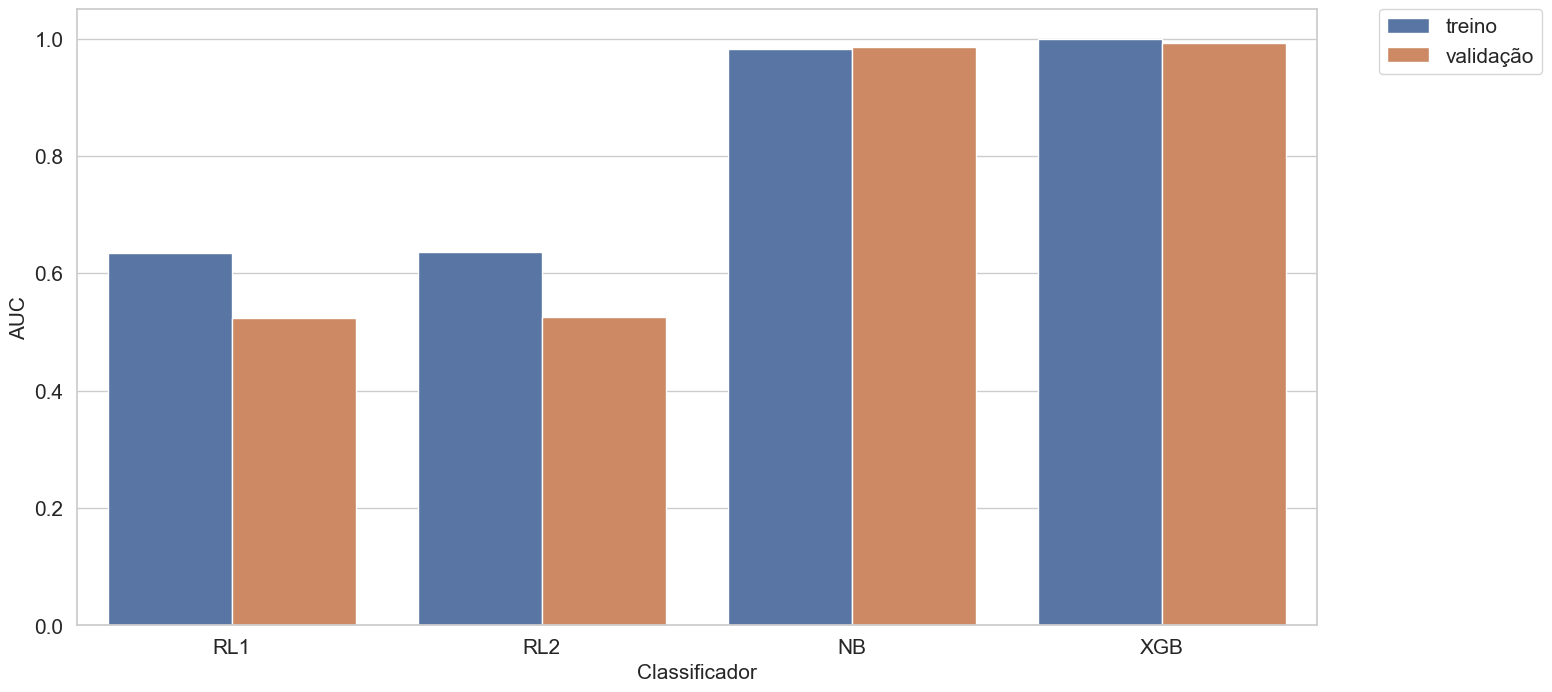

In [ ]:
# Construção do Plot
sns.set_style("whitegrid")
plt.figure(figsize = (16, 8))

# Gráfico de barras
ax = sns.barplot(x = 'classificador', y = 'auc', hue = 'data_set', data = df_results)
ax.set_xlabel('Classificador', fontsize = 15)
ax.set_ylabel('AUC', fontsize = 15)
ax.tick_params(labelsize = 15)

# Legenda
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0., fontsize = 15)

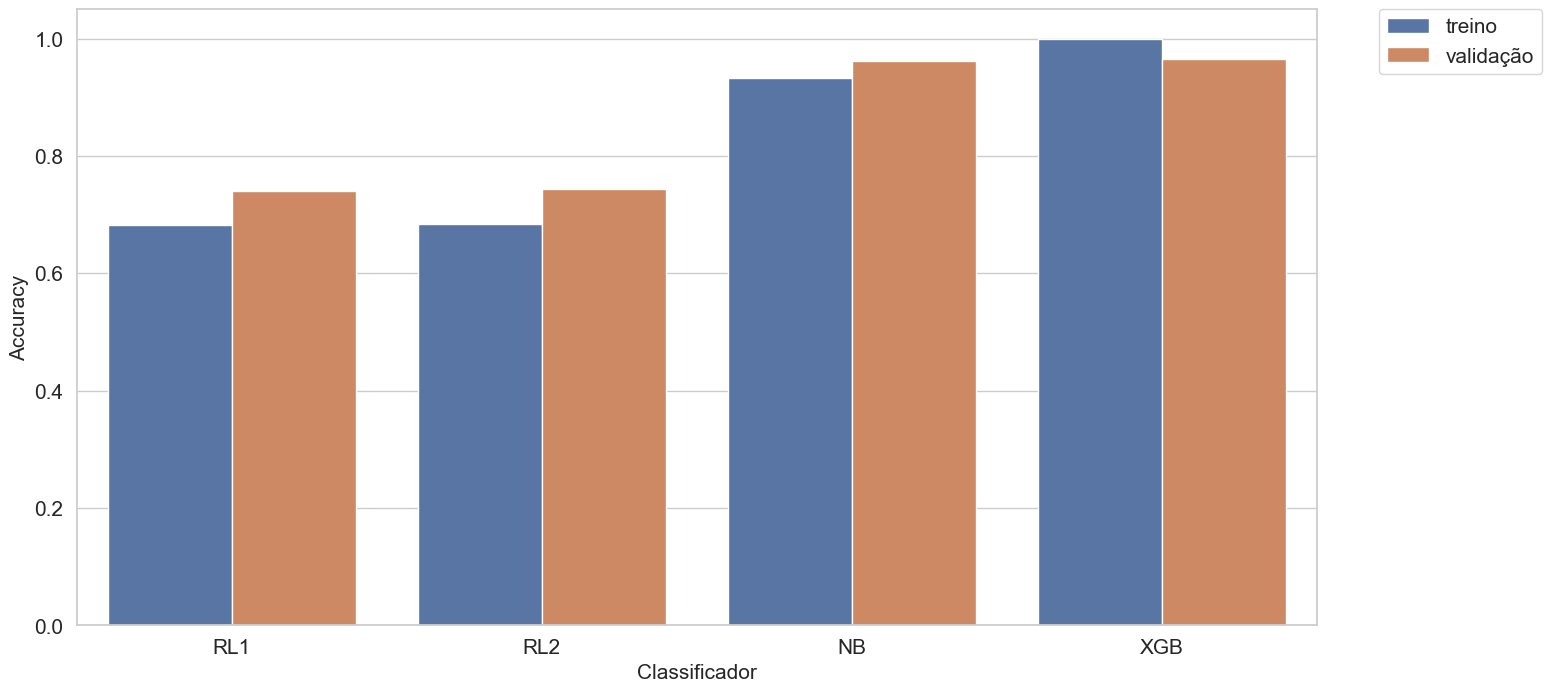

In [ ]:
# Construção do Plot
sns.set_style("whitegrid")
plt.figure(figsize = (16, 8))

# Gráfico de barras
ax = sns.barplot(x = 'classificador', y = 'accuracy', hue = 'data_set', data = df_results)
ax.set_xlabel('Classificador', fontsize = 15)
ax.set_ylabel('Accuracy', fontsize = 15)
ax.tick_params(labelsize = 15)

# Legenda
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0., fontsize = 15)

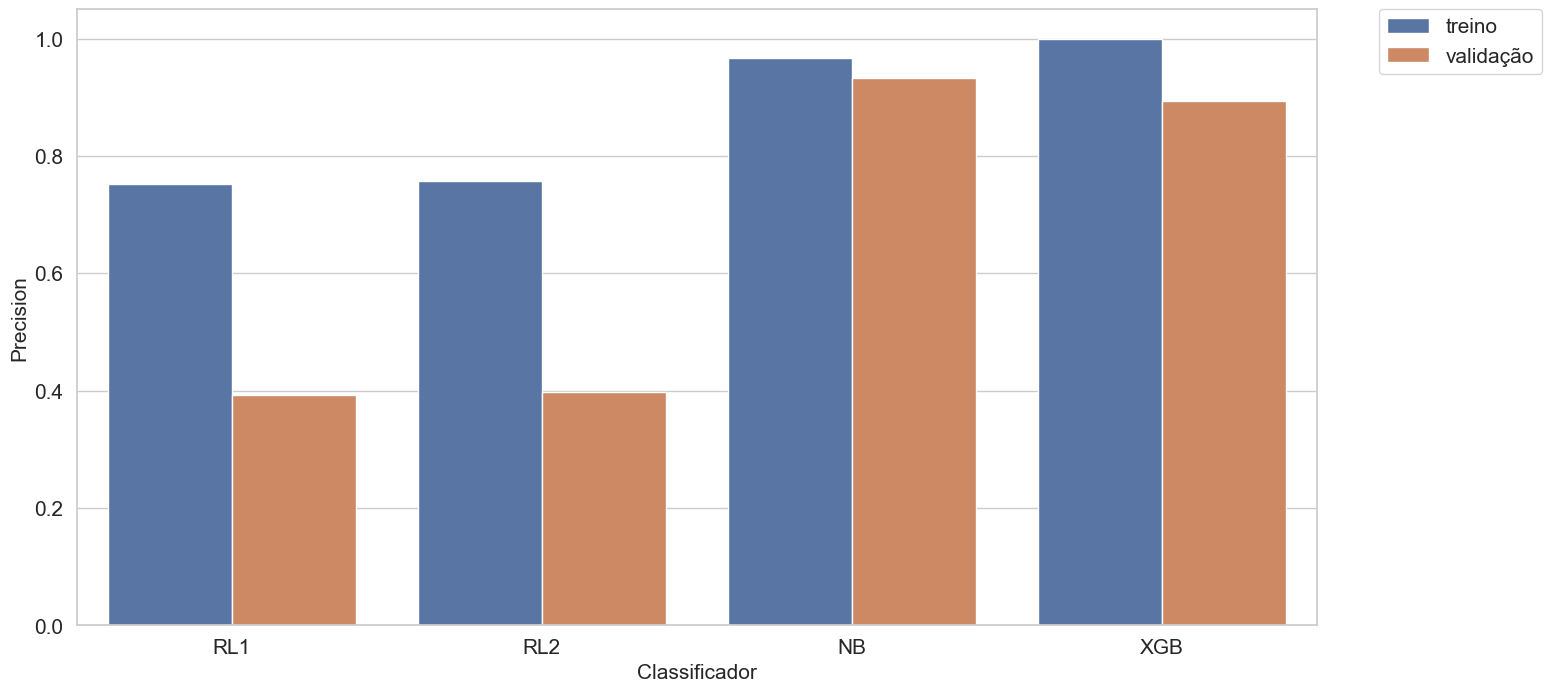

In [ ]:
# Construção do Plot
sns.set_style("whitegrid")
plt.figure(figsize = (16, 8))

# Gráfico de barras
ax = sns.barplot(x = 'classificador', y = 'precision', hue = 'data_set', data = df_results)
ax.set_xlabel('Classificador', fontsize = 15)
ax.set_ylabel('Precision', fontsize = 15)
ax.tick_params(labelsize = 15)

# Legenda
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0., fontsize = 15)

In [ ]:
# Grava o modelo em disco
pickle.dump(modelo_v4, open('melhor_modelo.pkl', 'wb'), protocol = 4)

In [ ]:
# Carrega o modelo, as colunas e o scaler
best_model = pickle.load(open('melhor_modelo.pkl','rb'))
cols_input = pickle.load(open('colunas_entrada.sav','rb'))
scaler = pickle.load(open('scaler.sav', 'rb'))

# Carrega os dados
df_train = pd.read_parquet('dados_treino.parquet')
df_valid = pd.read_parquet('dados_valid.parquet')
df_test = pd.read_parquet('dados_teste.parquet')

# Cria matrizes x e y

# X
X_train = df_train[cols_input].values
X_valid = df_valid[cols_input].values
X_test = df_test[cols_input].values

# Y
y_train = df_train['LABEL_VARIAVEL_TARGET'].values
y_valid = df_valid['LABEL_VARIAVEL_TARGET'].values
y_test = df_test['LABEL_VARIAVEL_TARGET'].values

# Aplica a transformação nos dados
X_train_tf = scaler.transform(X_train)
X_valid_tf = scaler.transform(X_valid)
X_test_tf = scaler.transform(X_test)

In [ ]:
# Previsões de probabilidade
y_train_preds = best_model.predict_proba(X_train_tf)[:,1]
y_valid_preds = best_model.predict_proba(X_valid_tf)[:,1]
y_test_preds = best_model.predict_proba(X_test_tf)[:,1]

In [ ]:
thresh = 0.5

print('\nTreinamento:\n')
train_auc, train_accuracy, train_recall, train_precision, train_specificity = print_report(y_train,
                                                                                           y_train_preds, 
                                                                                           thresh)

print('\nValidação:\n')
valid_auc, valid_accuracy, valid_recall, valid_precision, valid_specificity = print_report(y_valid,
                                                                                           y_valid_preds, 
                                                                                           thresh)

print('\nTeste:\n')
test_auc, test_accuracy, test_recall, test_precision, test_specificity = print_report(y_test,
                                                                                      y_test_preds, 
                                                                                      thresh)


Treinamento:

AUC:0.999
Acurácia:0.979
Recall:1.000
Precisão:0.905
Especificidade:0.974
 

Validação:

AUC:0.993
Acurácia:0.965
Recall:0.948
Precisão:0.893
Especificidade:0.970
 

Teste:

AUC:0.992
Acurácia:0.954
Recall:0.942
Precisão:0.838
Especificidade:0.957
 


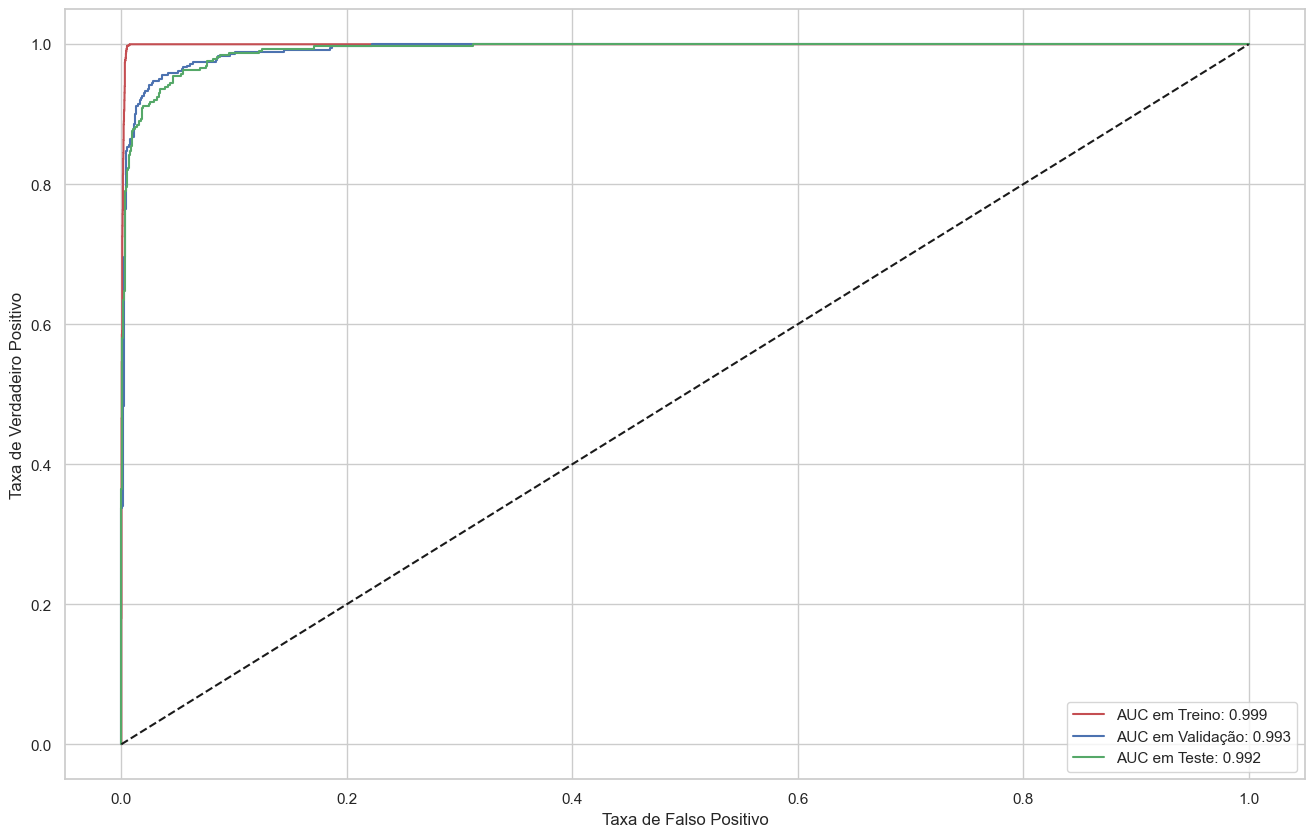

In [ ]:
# Calcula a curva ROC nos dados de treino
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_preds)
auc_train = roc_auc_score(y_train, y_train_preds)

# Calcula a curva ROC nos dados de validação
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, y_valid_preds)
auc_valid = roc_auc_score(y_valid, y_valid_preds)

# Calcula a curva ROC nos dados de teste
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_preds)
auc_test = roc_auc_score(y_test, y_test_preds)

# Plot
plt.figure(figsize=(16,10))
plt.plot(fpr_train, tpr_train, 'r-',label = 'AUC em Treino: %.3f'%auc_train)
plt.plot(fpr_valid, tpr_valid, 'b-',label = 'AUC em Validação: %.3f'%auc_valid)
plt.plot(fpr_test, tpr_test, 'g-',label = 'AUC em Teste: %.3f'%auc_test)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.legend()
plt.show()

In [ ]:
# Carregando dados de um novo cliente
novo_cliente = pd.read_csv('novos_dados.csv')

In [ ]:
novo_cliente

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,51,46,34,21,13,12,6,4,1,-4,...,-41,-16,2,22,33,45,56,67,69,63


In [ ]:
novo_cliente_scaled = scaler.transform(novo_cliente)

In [ ]:
novo_cliente_scaled

array([[ 0.28270678,  0.25209625,  0.19554432,  0.12977183,  0.08201421,
         0.06500265,  0.03479002,  0.02778467,  0.01403699, -0.01189195,
        -0.05324613, -0.08362858, -0.09441296, -0.09024475, -0.1020012 ,
        -0.06256608, -0.06637408, -0.07568914, -0.0371206 , -0.05257888,
        -0.06689507, -0.03905989, -0.00693807,  0.00924522,  0.00644452,
         0.01016988,  0.03619156,  0.06067021,  0.08707147,  0.0811692 ,
         0.06424778,  0.01357589, -0.00344403, -0.02478951, -0.00562658,
         0.01946295,  0.06101612,  0.10504648,  0.12447107,  0.15979721,
         0.16989217,  0.18559866,  0.17739785,  0.19673196,  0.19659787,
         0.19475478,  0.18464758,  0.14065564,  0.07856398,  0.03009377,
         0.01333507, -0.04301452, -0.09755117, -0.14206219, -0.16999714,
        -0.19112845, -0.19421544, -0.19315578, -0.18163475, -0.14303395,
        -0.10464213, -0.07116081, -0.04335574, -0.06978566, -0.06422583,
        -0.05769913, -0.04031793,  0.01146707,  0.0

In [ ]:
prob = best_model.predict_proba(novo_cliente_scaled)

In [ ]:
prob

array([[9.9998975e-01, 1.0271317e-05]], dtype=float32)

In [ ]:
prod = best_model.predict(novo_cliente_scaled)

In [ ]:
prod

array([0])

In [ ]:
# Carrega o modelo, as colunas e o scaler
best_model = pickle.load(open('melhor_modelo.pkl','rb'))
scaler = pickle.load(open('scaler.sav', 'rb'))

df_novo_cliente = pd.read_csv('novos_dados.csv')

df_novo_cliente_scaled = scaler.transform(df_novo_cliente)
best_model.predict(df_novo_cliente_scaled)

array([0])